<a href="https://colab.research.google.com/github/aleeseyon/AICodAgent/blob/main/Physics_guided_RWPGNN%2BSeis2Rock_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Direct Multi-Property Petrophysical Inversion from Pre-Stack Seismic Data
## Physics-Informed SVD–CNN Framework | Smeaheia Synthetic Dataset

**References:**
- Corrales, Hoteit & Ravasi (2024) — Seis2Rock, *Earth and Space Science*
- Das & Mukerji (2020) — PetroNet, *Geophysics* 85(5)

---
**Run order:** Part 0 → Part 1 → Part 2 → Part 3 → Part 4  
Upload `smeaheia_synthetic.npz` to `/content/` before running.


## Part 0 — Setup

In [83]:
!git clone --quiet https://github.com/DeepWave-KAUST/Seis2Rock.git
!pip install pylops --quiet
!pip install lasio
import sys; sys.path.insert(0, "Seis2Rock")


fatal: destination path 'Seis2Rock' already exists and is not an empty directory.


In [84]:
# ── Core imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import coherence as sp_coherence

# ── PyLops — wildcard imports exactly as reference ────────────────────────────
import pylops
from pylops.utils.wavelets            import *
from pylops.basicoperators            import *
from pylops.signalprocessing          import *
from pylops.avo.avo                   import *
from pylops.avo.poststack             import *
from pylops.optimization.leastsquares import *

# ── Seis2Rock package ─────────────────────────────────────────────────────────
from seis2rock.pem_seis2rock      import pem_seis2rock
from seis2rock.seis2rock_functions import (
    create_background_models_synthetic,
    avo_synthetic_gather_2D,
    extract_well_logs_from_2D,
    Seis2Rock_training,
    Seis2Rock_inference,
)
from seis2rock.seis2rock_utils import (
    plot_petrophysical_2D_sections,
    plot_elastic_2D_sections,
    plot_inversion_results_2D,
    plot_well_results_2Dsynthethic,
    plot_compare_b_reflectivities,
    plot_set_logs,
)

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print(f"PyLops {pylops.__version__} | PyTorch {torch.__version__} | device: {DEVICE}")


PyLops 2.6.0 | PyTorch 2.10.0+cpu | device: cpu


Grid  : 225 depth samples x 174 traces
Depth : 3500 - 6000 m
phi   : [0.080, 0.354]
Vsh   : [0.030, 1.000]
Sw    : [0.303,  1.000]
Grid  : 225 depth samples x 174 traces
Depth : 3500 - 6000 m
phi   : [0.080, 0.354]
Vsh   : [0.030, 1.000]
Sw    : [0.303,  1.000]


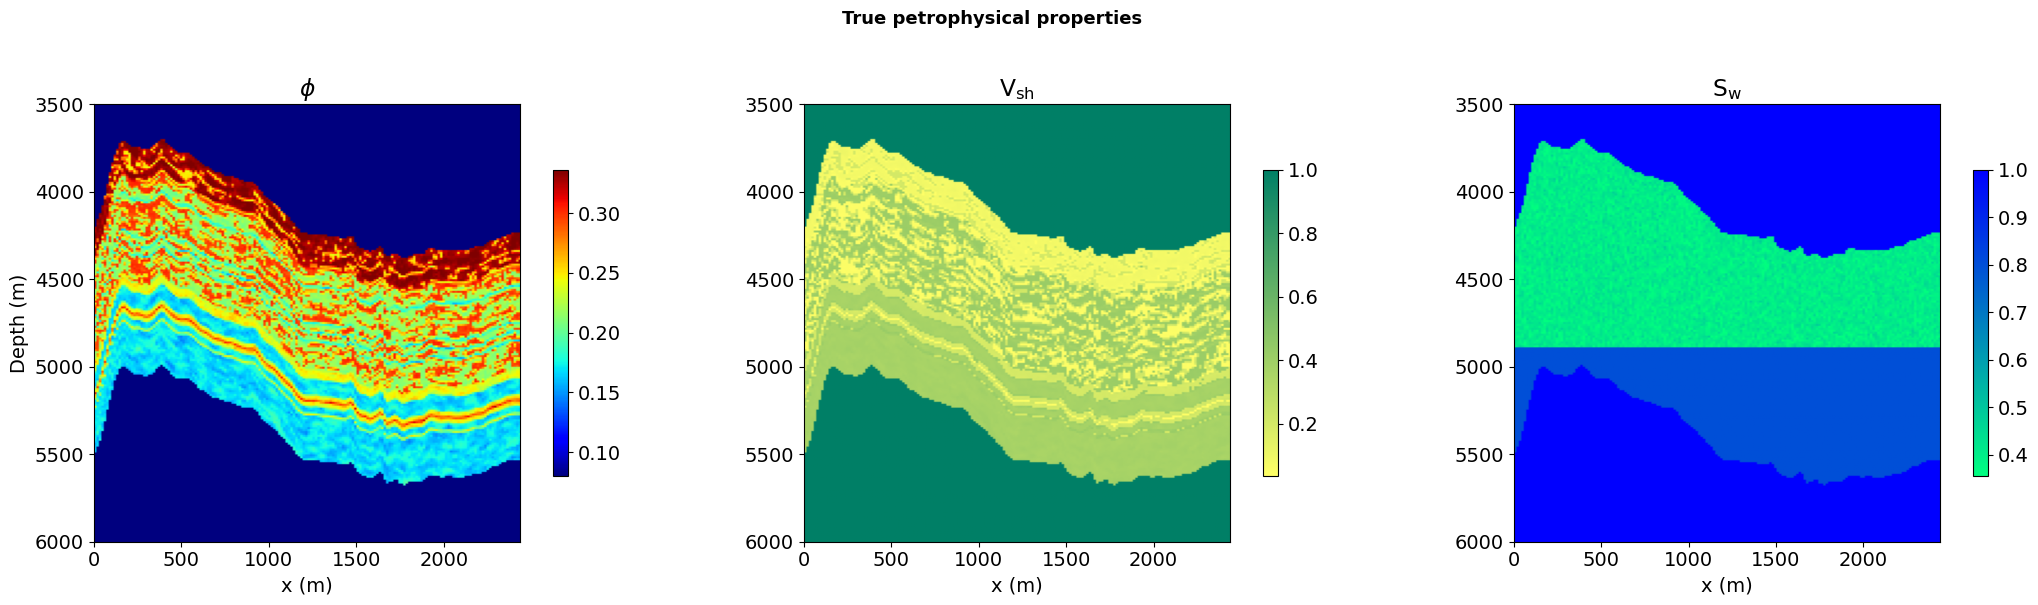

In [85]:
# ── Load Smeaheia synthetic dataset ───────────────────────────────────
# Edit SMEAHEIA_PATH below to run outside Colab. Default works on Colab after
# `from google.colab import files; files.upload()` (uncomment if needed).
# from google.colab import files; files.upload()
SMEAHEIA_PATH = 'smeaheia_synthetic.npz'   # change for local runs

# f = np.load(SMEAHEIA_PATH, allow_pickle=True)

# phi_2D          = f['phi'].astype(np.float32)
# vsh_2D          = f['vsh'].astype(np.float32)
# sw_2D           = f['sw'].astype(np.float32)
# sw_displaced_2D = f['sw_displaced'].astype(np.float32)
# depth           = f['depth']
# x_axis          = f['x_axis']
# NT, NX          = phi_2D.shape   # (225, 174)


# ── Load Smeaheia synthetic dataset ──────────────────────────────────────────
# Edit SMEAHEIA_PATH below to run outside Colab. Default works on Colab after
# `from google.colab import files; files.upload()` (uncomment if needed).
# from google.colab import files; files.upload()
# SMEAHEIA_PATH = 'smeaheia_synthetic.npz'   # change for local runs

f = np.load(SMEAHEIA_PATH, allow_pickle=True)

phi_2D          = f['phi'].astype(np.float32)
vsh_2D          = f['vsh'].astype(np.float32)
sw_2D           = f['sw'].astype(np.float32)
sw_displaced_2D = f['sw_displaced'].astype(np.float32)
depth           = f['depth']
x_axis          = f['x_axis']
phi_2D_back = np.load('/content/phi_pred_RWPGNN_100wells.npy').astype(np.float32)

NT, NX = phi_2D.shape
print(f"Grid  : {NT} depth samples x {NX} traces")
print(f"Depth : {depth[0]:.0f} - {depth[-1]:.0f} m")
print(f"phi   : [{phi_2D.min():.3f}, {phi_2D.max():.3f}]")
print(f"Vsh   : [{vsh_2D.min():.3f}, {vsh_2D.max():.3f}]")
print(f"Sw    : [{sw_2D.min():.3f},  {sw_2D.max():.3f}]")

print(f"Grid  : {NT} depth samples x {NX} traces")
print(f"Depth : {depth[0]:.0f} - {depth[-1]:.0f} m")
print(f"phi   : [{phi_2D.min():.3f}, {phi_2D.max():.3f}]")
print(f"Vsh   : [{vsh_2D.min():.3f}, {vsh_2D.max():.3f}]")
print(f"Sw    : [{sw_2D.min():.3f},  {sw_2D.max():.3f}]")

# extent for imshow (x_min, x_max, depth_max, depth_min)
ext = [x_axis[0], x_axis[-1], depth[-1], depth[0]]

fig = plot_petrophysical_2D_sections(phi_2D, vsh_2D, sw_2D, x_axis, depth, fontsize=14)
plt.suptitle('True petrophysical properties', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [86]:
original_phi_2D_back = np.load('/content/phi_pred_RWPGNN_100wells.npy').astype(np.float32)
print(f"Minimum value of original phi_pred_RWPGNN_100wells.npy (before NaN replacement): {np.nanmin(original_phi_2D_back):.3f}")

Minimum value of original phi_pred_RWPGNN_100wells.npy (before NaN replacement): 0.080


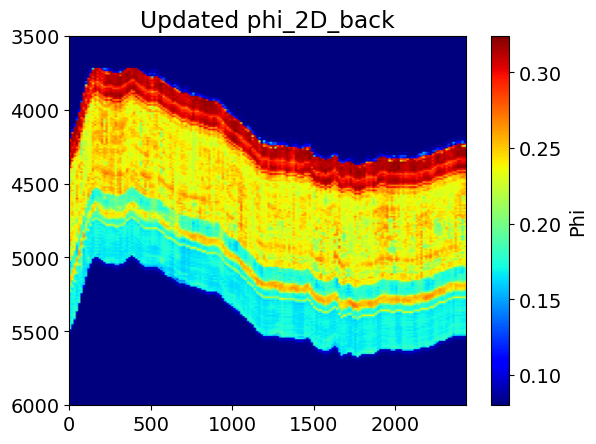

In [87]:
phi_2D_back = np.nan_to_num(phi_2D_back, nan=np.nanmin(original_phi_2D_back))
#

# extent for imshow (x_min, x_max, depth_max, depth_min)
ext = [x_axis[0], x_axis[-1], depth[-1], depth[0]]
plt.imshow(phi_2D_back, aspect='auto', cmap='jet', extent=ext)
plt.title('Updated phi_2D_back')
plt.colorbar(label='Phi')
plt.show()

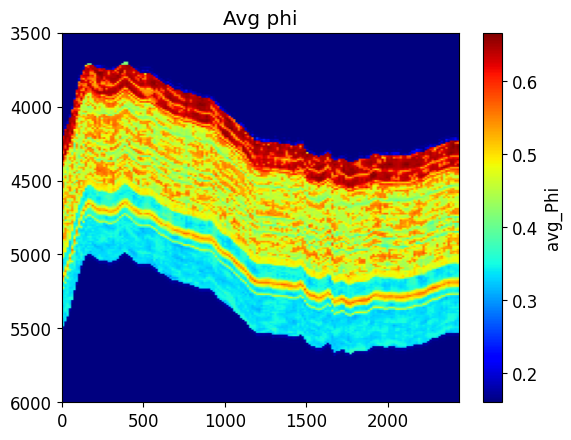

In [97]:
avg_phi = phi_2D + phi_2D_back

ext = [x_axis[0], x_axis[-1], depth[-1], depth[0]]
plt.imshow(avg_phi, aspect='auto', cmap='jet', extent=ext)
plt.title('Avg phi')
plt.colorbar(label='avg_Phi')
plt.show()

Computing AVO synthetic gather for background models...
Calculating matrix of optimal coefficients Cp...
Creating the new data term (Petrophysical coefficeints B)...
Done xD !
b_optAVO (3, 225, 174)  (3 properties x NT x NX)
Inverting phi ...
Inverting Vsh ...
Inverting Sw  ...
Inversion complete.


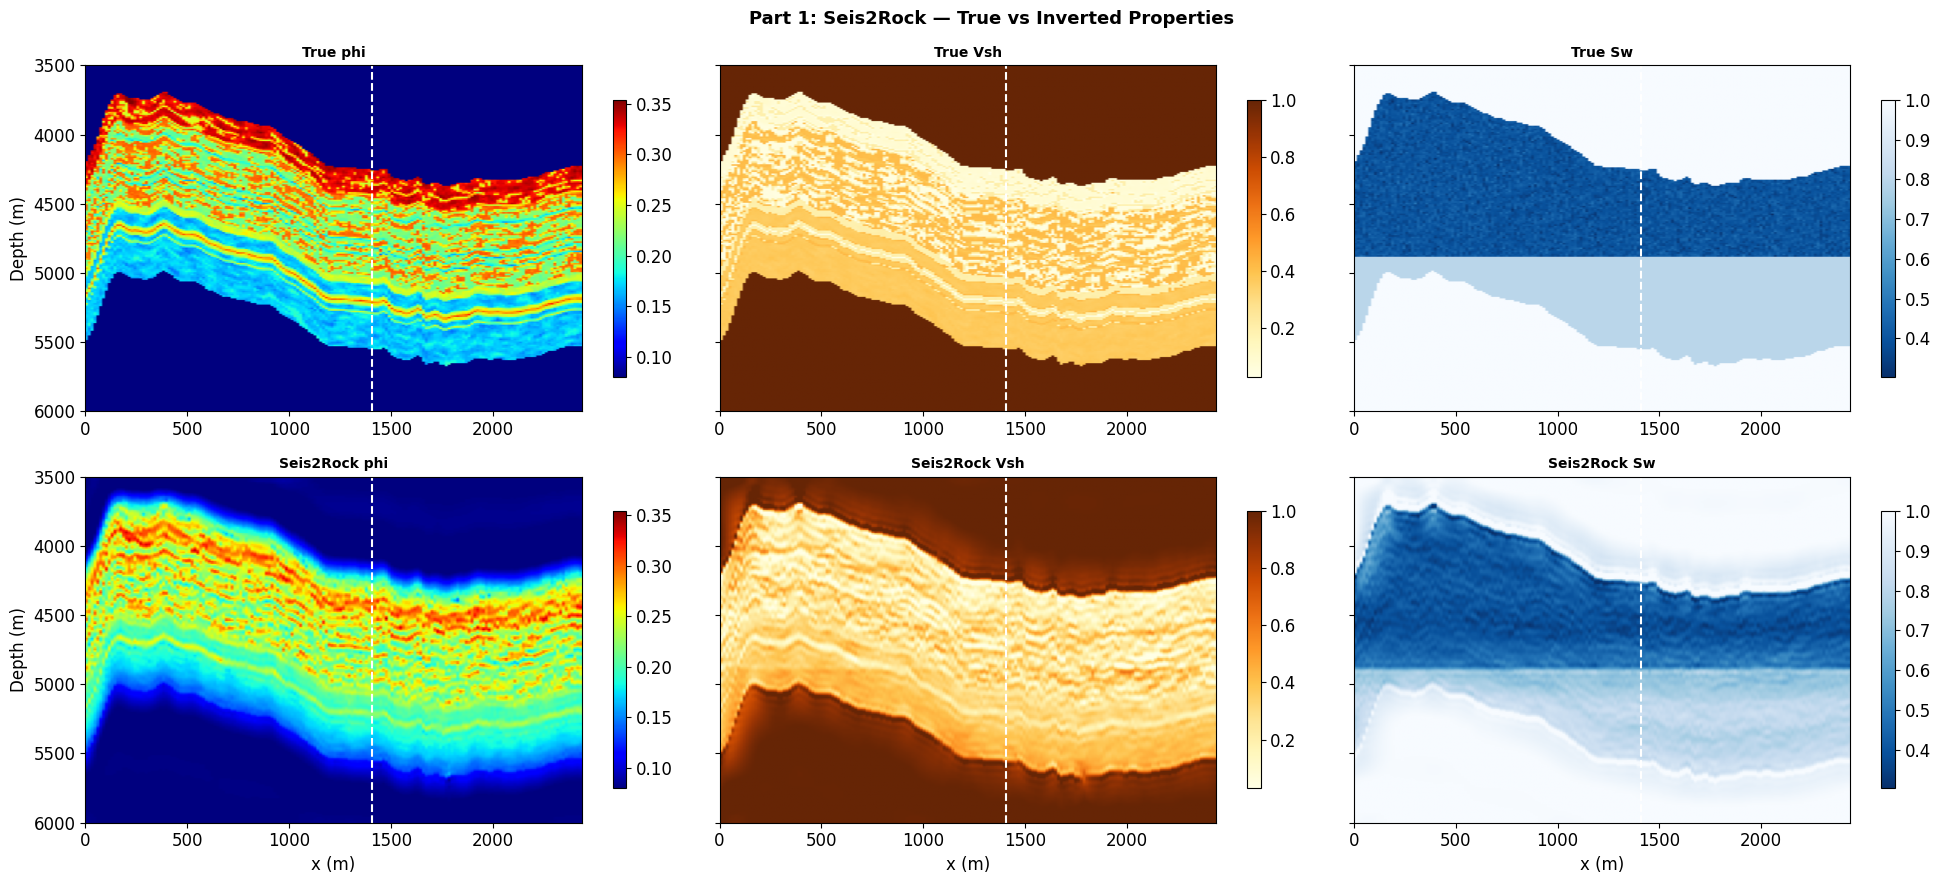

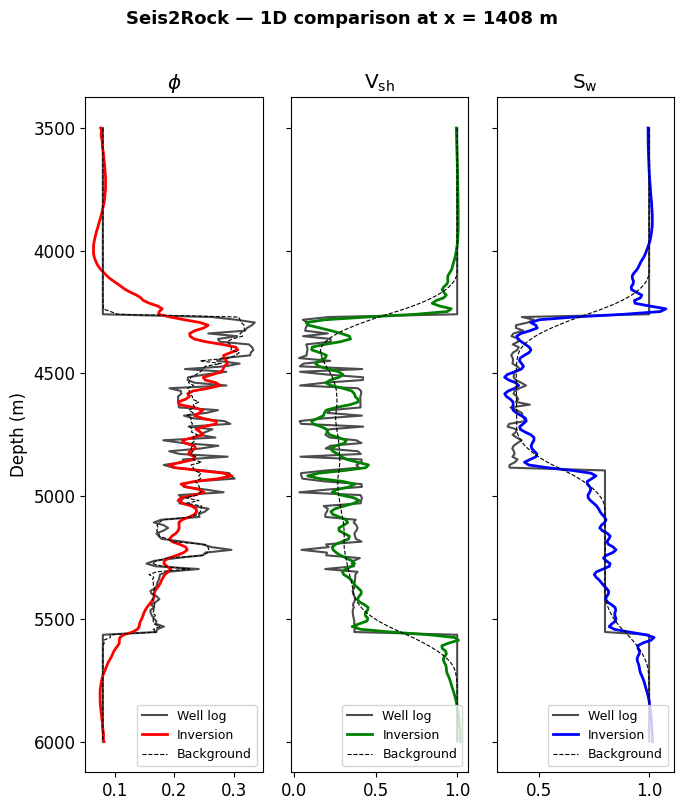

Seis2Rock phi : RMSE=0.03133  R2=0.8672  RRE=0.1734
Seis2Rock Vsh : RMSE=0.08890  R2=0.9457  RRE=0.1222
Seis2Rock Sw  : RMSE=0.05297  R2=0.9592  RRE=0.0650
Seis2Rock phi PSNR: 21.06 dB


In [98]:
# ── Seis2Rock inference → petrophysical reflectivities ───────────────────────
b_optAVO, r_zoeppritz_back, Cp, Hp, Cp_estimated = Seis2Rock_inference(
    vp=vp_2D_back.T, vs=vs_2D_back.T, rho=rho_2D_back.T,
    wav_est=wav, nt_wav=hcenter,
    dtheta=d.transpose(0, 2, 1),   # (NX, NTHETA, NT)
    Fp=Fp, Lp=Lp, Vp=Vp_svd,    # NOTE: Vp_svd here is SVD V-matrix component (cell 9), not velocity
    phi=phi, vsh=vsh, sw=sw,
    phi_back=phi_back, vsh_back=vsh_back, sw_back=sw_back,
    d=d_well,
    thetamin=thetamin, thetamax=thetamax, ntheta=ntheta)

print(f"b_optAVO {b_optAVO.shape}  (3 properties x NT x NX)")

# ── Regularised post-stack inversion ─────────────────────────────────────────
D_op = PoststackLinearModelling(wav, nt0=b_optAVO.shape[1],
                                spatdims=b_optAVO.shape[2], explicit=True, kind='forward')
D2op = Laplacian([b_optAVO.shape[1], b_optAVO.shape[2]], dtype='float64')

niter  = 50
lamba1 = np.sqrt(1e-2); damp1 = 10e-2
lamba2 = np.sqrt(1e-1); damp2 = 1e-2

def invert(b, x0, lamba, damp):
    return regularized_inversion(
        D_op, b.ravel(), Regs=[D2op], epsRs=[lamba],
        x0=x0.ravel(), **dict(iter_lim=niter, damp=damp))[0].reshape(x0.shape)

print("Inverting phi ..."); phi_s2r = invert(b_optAVO[0], phi_2D_back, lamba1, damp1)
print("Inverting Vsh ..."); vsh_s2r = invert(b_optAVO[1], vsh_2D_back, lamba2, damp2)
print("Inverting Sw  ..."); sw_s2r  = invert(b_optAVO[2], sw_2D_back,  lamba2, damp2)
print("Inversion complete.")

# ── Results figure: True vs Seis2Rock for all three properties ────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharey=True)
for col, (true, pred, lbl, cm) in enumerate([
        (phi_2D, phi_s2r, 'phi',  'jet'),
        (vsh_2D, vsh_s2r, 'Vsh',  'YlOrBr'),
        (sw_2D,  sw_s2r,  'Sw',   'Blues_r')]):
    for row, (data, rtag) in enumerate([(true, 'True'), (pred, 'Seis2Rock')]):
        ax = axes[row, col]
        v0, v1 = true.min(), true.max()
        im = ax.imshow(data, aspect='auto', cmap=cm, extent=ext, vmin=v0, vmax=v1)
        ax.axvline(x_axis[x_loc], color='white', lw=1.5, ls='--')
        ax.set_title(f'{rtag} {lbl}', fontweight='bold', fontsize=10)
        if col == 0: ax.set_ylabel('Depth (m)')
        if row == 1: ax.set_xlabel('x (m)')
        plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Part 1: Seis2Rock — True vs Inverted Properties',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_seis2rock_results.png', dpi=150, bbox_inches='tight'); plt.show()

# ── 1D well comparison ────────────────────────────────────────────────────────
fig = plot_well_results_2Dsynthethic(
    depth=depth,
    well_logs     = [phi, vsh, sw],
    inv_dense_reg = [phi_s2r, vsh_s2r, sw_s2r],
    backgrounds   = [phi_back, vsh_back, sw_back],
    x_loc=x_loc)
plt.suptitle(f'Seis2Rock — 1D comparison at x = {x_axis[x_loc]:.0f} m',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_seis2rock_well.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Metrics — all three properties ───────────────────────────────────────────
def _s2r_metrics(true2d, pred2d, name):
    rmse, r2, rre = compute_metrics(true2d, pred2d, mask_nans=True)
    print(f"Seis2Rock {name:<4}: RMSE={rmse:.5f}  R2={r2:.4f}  RRE={rre:.4f}")
    return rmse, r2, rre

s2r_phi_rmse_full, s2r_phi_r2_full, s2r_phi_rre_full = _s2r_metrics(phi_2D, phi_s2r, "phi")
s2r_vsh_rmse,      s2r_vsh_r2,      s2r_vsh_rre      = _s2r_metrics(vsh_2D, vsh_s2r, "Vsh")
s2r_sw_rmse,       s2r_sw_r2,       s2r_sw_rre       = _s2r_metrics(sw_2D,  sw_s2r,  "Sw")
# PSNR retained for phi (used historically as the inversion-quality benchmark
# in Corrales et al. 2024, Table 1)
_mse_phi = mean_squared_error(phi_2D.ravel(), phi_s2r.ravel())
print(f"Seis2Rock phi PSNR: {10 * np.log10(phi_2D.max()**2 / _mse_phi):.2f} dB")


In [ ]:
from sklearn.metrics import mean_squared_error
mse_phi = mean_squared_error(phi_2D.ravel(), phi_s2r.ravel())
print(f"Mean Squared Error (MSE) between phi_2D and phi_s2r: {mse_phi:.5f}")

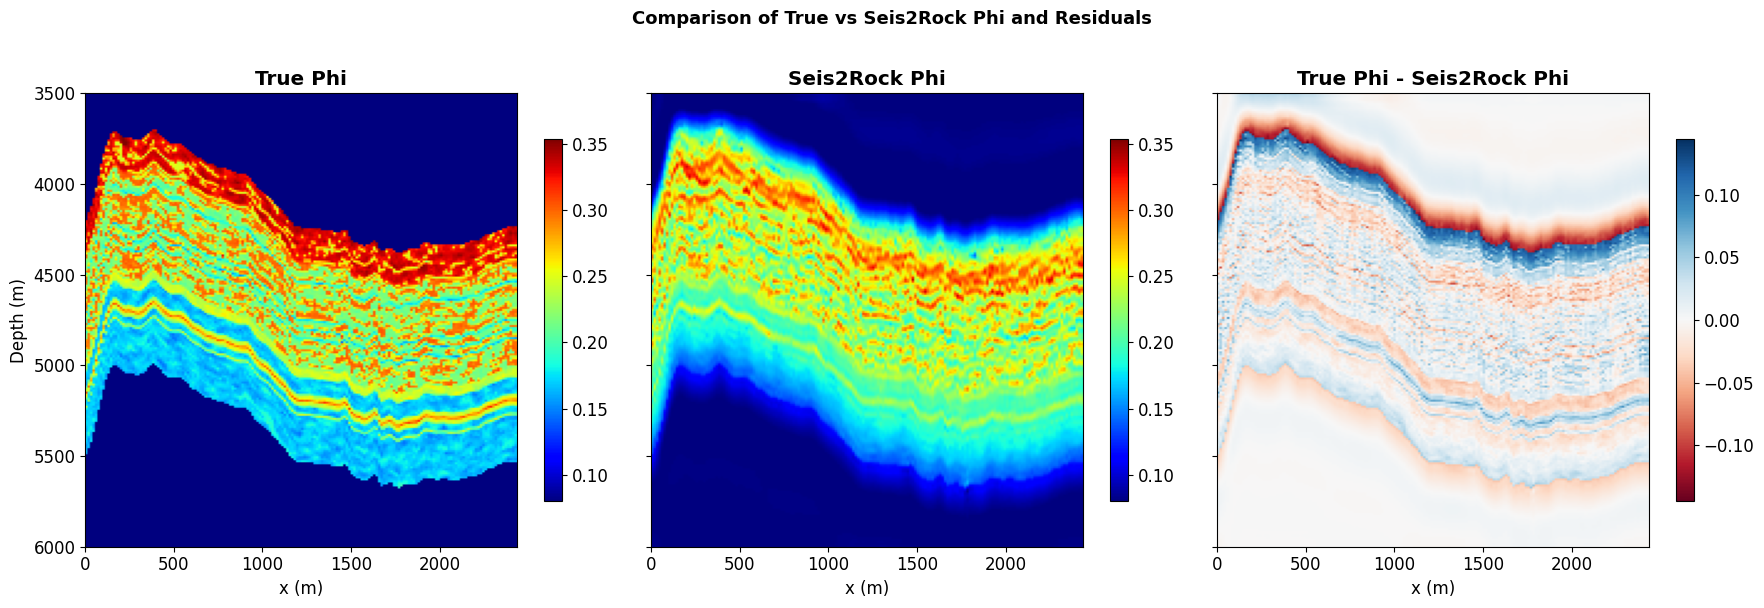

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

vmin_phi, vmax_phi = phi_2D.min(), phi_2D.max()

# Plot 1: True Phi
im_true = axes[0].imshow(phi_2D, aspect='auto', cmap='jet', extent=ext, vmin=vmin_phi, vmax=vmax_phi)
axes[0].set_title('True Phi', fontweight='bold')
axes[0].set_ylabel('Depth (m)')
axes[0].set_xlabel('x (m)')
plt.colorbar(im_true, ax=axes[0], shrink=0.8)

# Plot 2: Seis2Rock Phi
im_s2r = axes[1].imshow(phi_s2r, aspect='auto', cmap='jet', extent=ext, vmin=vmin_phi, vmax=vmax_phi)
axes[1].set_title('Seis2Rock Phi', fontweight='bold')
axes[1].set_xlabel('x (m)')
plt.colorbar(im_s2r, ax=axes[1], shrink=0.8)

# Calculate residuals
phi_res_s2r = phi_2D - phi_s2r

# Determine vmin/vmax for residuals (symmetric around 0)
vmax_res = np.abs(phi_res_s2r).max()
vmin_res = -vmax_res

# Plot 3: True Phi - Seis2Rock Phi
im_res_s2r = axes[2].imshow(phi_res_s2r, aspect='auto', cmap='RdBu', extent=ext, vmin=vmin_res, vmax=vmax_res)
axes[2].set_title('True Phi - Seis2Rock Phi', fontweight='bold')
axes[2].set_xlabel('x (m)')
plt.colorbar(im_res_s2r, ax=axes[2], shrink=0.8)

plt.suptitle('Comparison of True vs Seis2Rock Phi and Residuals', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

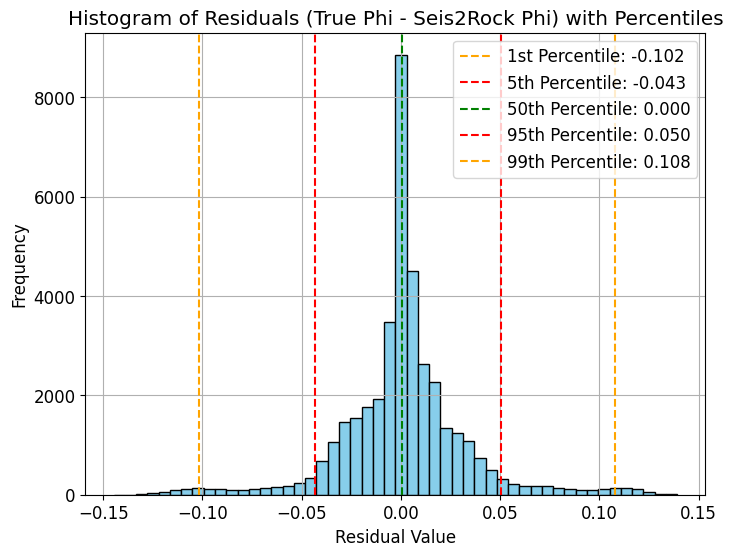

In [106]:
plt.figure(figsize=(8, 6))
hist_data = phi_res_s2r.ravel()
plt.hist(hist_data, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Residuals (True Phi - Seis2Rock Phi) with Percentiles')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)

# Calculate percentiles
p1 = np.percentile(hist_data, 1)
p5 = np.percentile(hist_data, 5)
p50 = np.percentile(hist_data, 50)
p95 = np.percentile(hist_data, 95)
p99 = np.percentile(hist_data, 99)

# Add vertical lines for percentiles
plt.axvline(p1, color='orange', linestyle='--', linewidth=1.5, label=f'1st Percentile: {p1:.3f}')
plt.axvline(p5, color='red', linestyle='--', linewidth=1.5, label=f'5th Percentile: {p5:.3f}')
plt.axvline(p50, color='green', linestyle='--', linewidth=1.5, label=f'50th Percentile: {p50:.3f}')
plt.axvline(p95, color='red', linestyle='--', linewidth=1.5, label=f'95th Percentile: {p95:.3f}')
plt.axvline(p99, color='orange', linestyle='--', linewidth=1.5, label=f'99th Percentile: {p99:.3f}')

# Add legend to show percentile values
plt.legend()

plt.show()